# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

## CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

From a data science perspective, the business objective can be reframed as a **supervised learning problem**, specifically a regression task, where the goal is to predict the continuous target variable price of used vehicles.

Given a dataset containing vehicle attributes (e.g., age, mileage, fuel type, manufacturer, and technical specifications), the task is to learn a mapping function f(X)→y that estimates vehicle price based on input features. In addition to prediction, the objective includes quantifying feature importance and understanding relationships between variables to identify the key drivers of price.

This involves standard steps such as data preprocessing, feature engineering, model training, and evaluation (e.g., using MSE/RMSE), as well as applying interpretability techniques (e.g., permutation importance) to translate model outputs into actionable business insights.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

To move from business understanding to effective modeling, the first step is a structured exploratory data analysis (EDA) and data quality assessment. The following steps outline how to get familiar with the dataset and identify potential issues:

#### Understand the Dataset Structure

Begin by examining the shape of the dataset, feature names, and data types using methods such as `.shape`, `.info()`, and `.describe()`. This helps identify:
- Numerical vs categorical variables
- Potential target variable(s)
- Features that may require preprocessing
- Unexpected or inconsistent data types

#### Inspect duplicate and missing Values 

Evaluate the amount and distribution of missing data using `.isna().sum()` and percentage calculations. Missing values can reveal:
- Data collection problems
- Features with low usefulness
- The need for imputation or feature removal
- Check for Duplicates and Inconsistencies

#### Analyze Target Variable Distribution

Study the distribution of the target variable (e.g., vehicle price) using histograms and summary statistics. This helps detect:
- Skewed distributions
- Extreme outliers
- Zero or invalid values

If the distribution is heavily skewed, transformations such as `log` or `log1p` may improve model performance.

#### Detect Outliers and Unrealistic Values
- Vehicles priced at \$0
- Extremely high mileage
- Impossible manufacturing years

Outliers can distort regression models and may need to be capped or removed using percentile thresholds.

#### Explore Categorical Features
Review the frequency and uniqueness of categorical variables using `.value_counts()`. This helps identify:
- Rare categories
- Misspellings or inconsistent labels
- High-cardinality features such as model names or regions

Features with too many unique values may require grouping or encoding strategies.

#### Engineer Business-Relevant Features
Create features that better represent real-world behavior, such as:

- Vehicle age from manufacturing year
- Log-transformed odometer readings
- Grouped title status or vehicle types

Feature engineering often improves both interpretability and predictive performance.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [296]:
#Importing required Python's libraries

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, TransformedTargetRegressor, ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import pandas as pd
import warnings
from IPython.display import display, HTML

In [297]:
#Load cars dataset to Pandas DataFrame

vehicles = pd.read_csv ("data/vehicles.csv")

In [298]:
#Print 5 samples of the data

vehicles.sample(5)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
198364,7313860331,detroit metro,1850,2005.0,ford,f-150,good,NaN,gas,211000.0,clean,other,NaN,NaN,NaN,NaN,white,mi
217221,7316544645,southwest MN,8900,1961.0,chevrolet,apache,good,6 cylinders,gas,112000.0,clean,manual,NaN,rwd,full-size,pickup,blue,mn
384931,7302199914,waco,41999,2014.0,ford,f250,NaN,NaN,diesel,161533.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,tx
213684,7316932050,minneapolis / st paul,3500,2004.0,hyundai,santa fe,good,6 cylinders,gas,157897.0,clean,automatic,KM8SC73E24U824690,4wd,full-size,SUV,black,mn
44454,7313876966,palm springs,2800,2002.0,honda,civic 02 2dr,good,4 cylinders,gas,166000.0,clean,automatic,NaN,NaN,NaN,NaN,NaN,ca


In [299]:
#Check for duplicate records in the dataset

vehicles.duplicated().sum()

np.int64(0)

In [300]:
#Get information about vehicles dataset

vehicles.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

In [301]:
#Calculating the percentage of missing values for each column in the vehicles DataFrame and sorting them from highest to lowest.

(vehicles.isna().mean()*100).sort_values(ascending=False)

size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
region           0.000000
id               0.000000
price            0.000000
state            0.000000
dtype: float64

In [302]:
#Features to delete

cols_to_drop = [
    'id',          # not useful
    'VIN',         # not useful
    'region',      # not useful (404 unique values)
    'size',        # missing more than 71% values
    'model'        # this is not a clean categorical feature, but rather noisy, unstructured texttypos and variations, very large number of unique values 
]

vehicles = vehicles.drop (columns = cols_to_drop)

In [303]:
#Convert "year" feature to car's age
current_year = 2026  #

vehicles['age'] = current_year - vehicles['year']

vehicles['age'] = vehicles['age'].fillna(
    vehicles['age'].median()
)

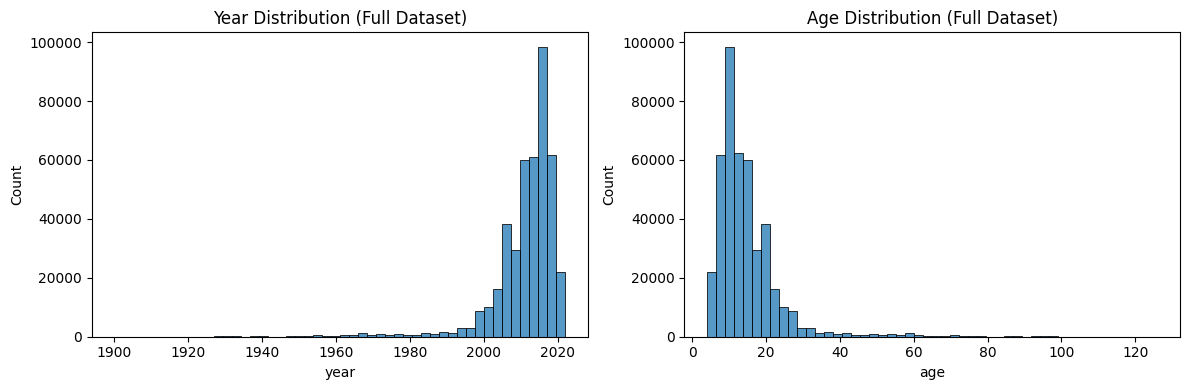

In [304]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(vehicles['year'], bins=50, ax=axes[0])
axes[0].set_title('Year Distribution (Full Dataset)')

sns.histplot(vehicles['age'], bins=50, ax=axes[1])
axes[1].set_title('Age Distribution (Full Dataset)')

plt.tight_layout()
plt.show()

In [305]:
#Remove outliers
vehicles = vehicles[(vehicles['age'] >= 0) & (vehicles['age'] <= 40)]
vehicles = vehicles.drop(columns=['year'])

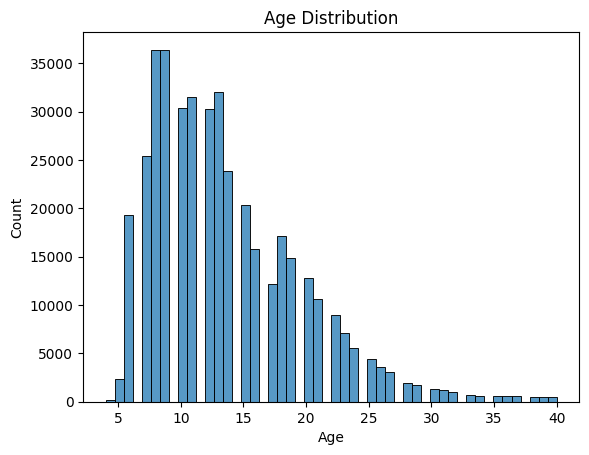

In [306]:
sns.histplot(vehicles['age'], bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

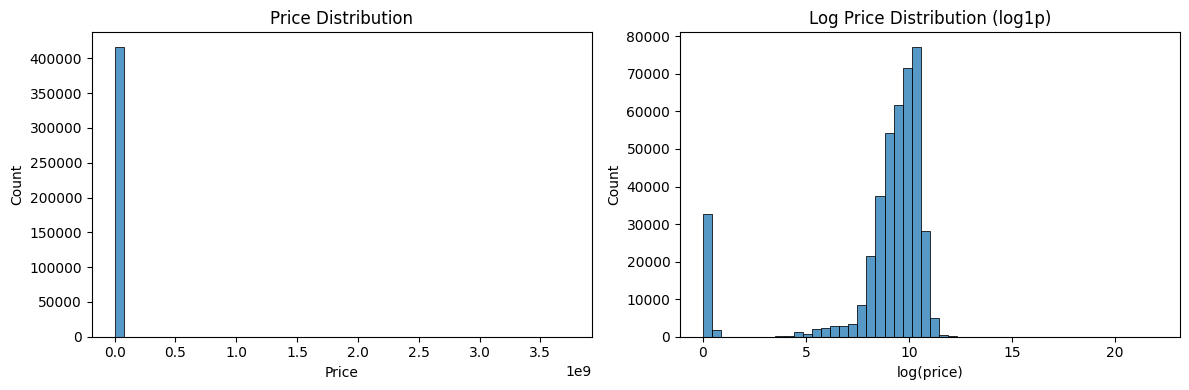

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(vehicles['price'], bins=50, ax=axes[0])
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(vehicles['price']), bins=50, ax=axes[1])
axes[1].set_title('Log Price Distribution (log1p)')
axes[1].set_xlabel('log(price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [308]:
low = 500
high = vehicles['price'].quantile(0.99)
vehicles = vehicles[(vehicles['price'] >= low) & (vehicles['price'] <= high)]

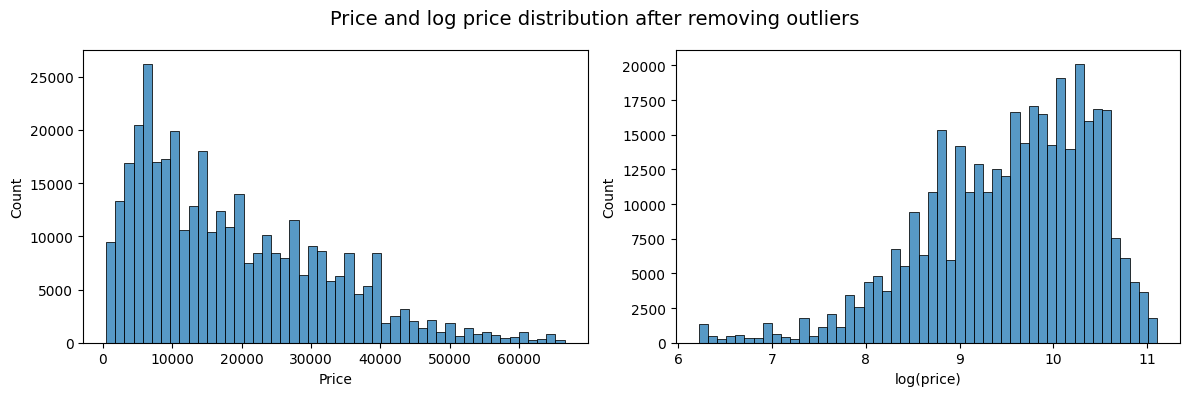

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle('Price and log price distribution after removing outliers', fontsize=14)

sns.histplot(vehicles['price'], bins=50, ax=axes[0])
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(vehicles['price']), bins=50, ax=axes[1])
axes[1].set_xlabel('log(price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

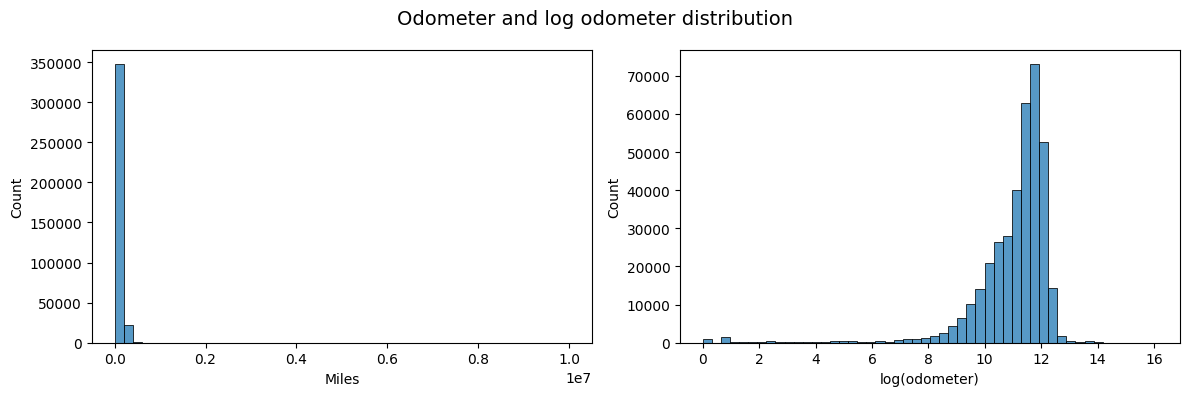

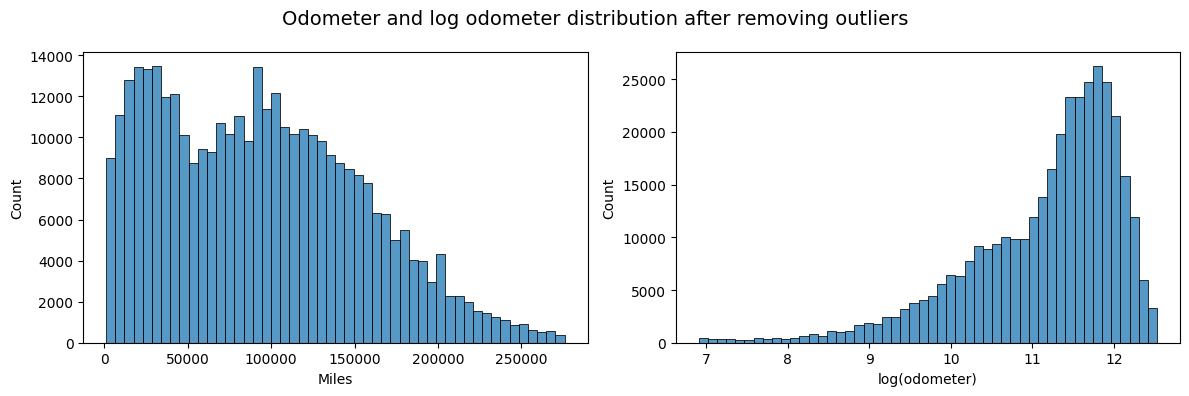

In [310]:
#Fill Nan for "odometer" column
vehicles['odometer'] = vehicles['odometer'].fillna(
    vehicles['odometer'].median()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Odometer and log odometer distribution', fontsize=14)

sns.histplot(vehicles['odometer'], bins=50, ax=axes[0])
axes[0].set_xlabel('Miles')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(vehicles['odometer']), bins=50, ax=axes[1])
axes[1].set_xlabel('log(odometer)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

vehicles = vehicles[vehicles['odometer'] > 10]
low, high = vehicles['odometer'].quantile([0.01, 0.99])
vehicles = vehicles[(vehicles['odometer'] >= low) & (vehicles['odometer'] <= high)]

vehicles['odometer_log'] = np.log1p(vehicles['odometer'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fig.suptitle('Odometer and log odometer distribution after removing outliers', fontsize=14)

sns.histplot(vehicles['odometer'], bins=50, ax=axes[0])
axes[0].set_xlabel('Miles')
axes[0].set_ylabel('Count')

sns.histplot(np.log1p(vehicles['odometer']), bins=50, ax=axes[1])
axes[1].set_xlabel('log(odometer)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [311]:
#Fill Nan for fuel column
vehicles['fuel'] = vehicles['fuel'].fillna('unknown')

vehicles['fuel'].unique()

<StringArray>
['unknown', 'gas', 'other', 'diesel', 'hybrid', 'electric']
Length: 6, dtype: str

In [312]:
vehicles['cylinders'].unique()

<StringArray>
[           nan,  '8 cylinders',  '6 cylinders',  '4 cylinders',
  '5 cylinders',        'other',  '3 cylinders', '10 cylinders',
 '12 cylinders']
Length: 9, dtype: str

In [313]:
vehicles['cylinders_num'] = (
    vehicles['cylinders']
    .str.extract(r'(\d+)')
    .astype(float)
)

vehicles['cylinders_missing'] = vehicles['cylinders_num'].isna().astype(int)

vehicles['cylinders_num'] = vehicles['cylinders_num'].fillna(
    vehicles['cylinders_num'].median()
)

vehicles = vehicles.drop(columns=['cylinders'])

In [314]:
vehicles['transmission'] = vehicles['transmission'].fillna('unknown')
vehicles['transmission'].unique()

<StringArray>
['unknown', 'other', 'automatic', 'manual']
Length: 4, dtype: str

In [315]:
condition_order = {
    'salvage': 0,
    'fair': 1,
    'good': 2,
    'excellent': 3,
    'like new': 4,
    'new': 5
}

vehicles['condition_num'] = vehicles['condition'].map(condition_order)

vehicles['condition_missing'] = vehicles['condition_num'].isna().astype(int)

vehicles['condition_num'] = vehicles['condition_num'].fillna(
    vehicles['condition_num'].median()
)

vehicles = vehicles.drop(columns=['condition'])

In [316]:
vehicles['drive'] = vehicles['drive'].fillna('unknown')
vehicles['drive'].unique()

<StringArray>
['unknown', 'rwd', '4wd', 'fwd']
Length: 4, dtype: str

In [317]:
vehicles['type'] = vehicles['type'].fillna('unknown')

type_map = {
    'pickup': 'truck',
    'truck': 'truck',

    'SUV': 'SUV',
    'wagon': 'SUV',
    'offroad': 'SUV',

    'sedan': 'car',
    'coupe': 'car',
    'hatchback': 'car',
    'convertible': 'car',

    'van': 'van',
    'mini-van': 'van',
    'bus': 'van',

    'other': 'other',
    'unknown': 'other'
}

vehicles['type_grouped'] = vehicles['type'].map(type_map)

vehicles = vehicles.drop(columns=['type'])

In [318]:
vehicles['title_status'] = vehicles['title_status'].fillna('unknown')

vehicles['title_status'].unique()

<StringArray>
['unknown', 'clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only']
Length: 7, dtype: str

In [319]:
title_map = {
    'clean': 'clean',

    'rebuilt': 'rebuilt',
    'lien': 'rebuilt',

    'salvage': 'salvage',

    'parts only': 'bad',
    'missing': 'bad',

    'unknown': 'other'
}

vehicles['title_grouped'] = vehicles['title_status'].map(title_map)
vehicles = vehicles.drop(columns=['title_status'])

vehicles['title_grouped'].unique()

<StringArray>
['other', 'clean', 'rebuilt', 'salvage', 'bad']
Length: 5, dtype: str

In [320]:
vehicles['manufacturer'].value_counts()

manufacturer
ford               58848
chevrolet          44784
toyota             29927
honda              18939
nissan             16612
jeep               16035
ram                15393
gmc                14262
bmw                13088
dodge              10957
mercedes-benz       9464
hyundai             9004
subaru              8582
volkswagen          8005
lexus               7475
kia                 7191
audi                6909
cadillac            6050
acura               5472
chrysler            5317
mazda               4818
buick               4809
infiniti            4358
lincoln             3779
volvo               3000
mitsubishi          2886
mini                2182
pontiac             1829
rover               1792
jaguar              1749
porsche             1125
saturn              1040
mercury              910
alfa-romeo           820
tesla                784
fiat                 716
harley-davidson      121
aston-martin          11
land rover            11
ferrari     

In [321]:
vehicles['manufacturer'] = vehicles['manufacturer'].fillna('unknown')

luxury_brands = [
    'acura','alfa-romeo','aston-martin','audi','bmw','cadillac',
    'ferrari','infiniti','jaguar','land rover','lexus','lincoln',
    'mercedes-benz','porsche','rover','tesla','volvo','morgan'
]

vehicles['is_luxury'] = (
    vehicles['manufacturer']
    .str.lower()
    .isin(luxury_brands)
    .astype(int)
)

top = vehicles['manufacturer'].value_counts().nlargest(20).index
vehicles['manufacturer'] = vehicles['manufacturer'].where(
    vehicles['manufacturer'].isin(top),
    'other'
)

In [322]:
vehicles['paint_color'] = vehicles['paint_color'].fillna('unknown')

color_map = {
    'white': 'light',
    'silver': 'light',
    'grey': 'neutral',

    'black': 'dark',
    'brown': 'dark',

    'blue': 'color',
    'red': 'color',
    'green': 'color',
    'yellow': 'color',
    'orange': 'color',
    'purple': 'color',

    'custom': 'other',
    'unknown': 'other'
}

vehicles['color_grouped'] = vehicles['paint_color'].map(color_map)
vehicles = vehicles.drop(columns=['paint_color'])

In [323]:
region_map = {
    # West
    'WA': 'West', 'OR': 'West', 'CA': 'West', 'NV': 'West',
    'ID': 'West', 'MT': 'West', 'WY': 'West', 'UT': 'West',
    'CO': 'West', 'AZ': 'West', 'NM': 'West', 'AK': 'West', 'HI': 'West',

    # Midwest
    'ND': 'Midwest', 'SD': 'Midwest', 'NE': 'Midwest', 'KS': 'Midwest',
    'MN': 'Midwest', 'IA': 'Midwest', 'MO': 'Midwest',
    'WI': 'Midwest', 'IL': 'Midwest', 'MI': 'Midwest',
    'IN': 'Midwest', 'OH': 'Midwest',

    # South
    'DE': 'South', 'MD': 'South', 'DC': 'South', 'VA': 'South',
    'WV': 'South', 'NC': 'South', 'SC': 'South', 'GA': 'South',
    'FL': 'South', 'KY': 'South', 'TN': 'South',
    'MS': 'South', 'AL': 'South',
    'OK': 'South', 'TX': 'South', 'AR': 'South', 'LA': 'South',

    # Northeast
    'ME': 'Northeast', 'NH': 'Northeast', 'VT': 'Northeast',
    'MA': 'Northeast', 'RI': 'Northeast', 'CT': 'Northeast',
    'NY': 'Northeast', 'NJ': 'Northeast', 'PA': 'Northeast'
}
vehicles['state'] = vehicles['state'].str.upper()
vehicles['region'] = vehicles['state'].map(region_map)
vehicles['region'] = vehicles['region'].fillna('Other')
vehicles = vehicles.drop(columns=['state'])

In [324]:
(vehicles.isna().mean()*100).sort_values(ascending=False)

price                0.0
manufacturer         0.0
fuel                 0.0
odometer             0.0
transmission         0.0
drive                0.0
age                  0.0
odometer_log         0.0
cylinders_num        0.0
cylinders_missing    0.0
condition_num        0.0
condition_missing    0.0
type_grouped         0.0
title_grouped        0.0
is_luxury            0.0
color_grouped        0.0
region               0.0
dtype: float64

In [325]:
#After data cleaning and preprocessing, the dataframe is fully populated and ready for machine learning.

In [326]:
vehicles.sample(10, random_state=42)

,price,manufacturer,fuel,odometer,transmission,drive,age,odometer_log,cylinders_num,cylinders_missing,condition_num,condition_missing,type_grouped,title_grouped,is_luxury,color_grouped,region
392667,12998,ford,gas,39385.0,automatic,rwd,22.0,10.581166,6.0,1,2.0,1,truck,clean,0,light,South
122963,27000,mercedes-benz,gas,49909.0,automatic,4wd,8.0,10.817977,4.0,0,3.0,0,car,clean,1,color,South
390375,6250,nissan,gas,157000.0,automatic,fwd,13.0,11.964007,4.0,0,2.0,0,car,clean,0,dark,South
132248,20999,ford,gas,140522.0,automatic,4wd,14.0,11.853126,6.0,0,2.0,1,truck,clean,0,dark,West
169475,6990,volkswagen,hybrid,113119.0,automatic,fwd,13.0,11.636204,4.0,0,4.0,0,car,clean,0,light,Midwest
154124,4500,ford,gas,2000.0,automatic,4wd,20.0,7.601402,8.0,0,2.0,0,truck,clean,0,color,Midwest
339267,35995,ford,gas,27500.0,manual,rwd,11.0,10.221978,8.0,0,4.0,0,car,clean,0,neutral,Northeast
395114,9990,ford,gas,89671.0,automatic,4wd,15.0,11.403914,6.0,1,2.0,1,SUV,clean,0,light,South
59974,27500,unknown,gas,102257.0,automatic,rwd,14.0,11.535254,8.0,0,3.0,0,truck,clean,0,light,West
334376,8990,ford,gas,166440.0,automatic,4wd,20.0,12.022396,8.0,0,2.0,1,truck,clean,0,other,Northeast


In [327]:
vehicles.info()

<class 'pandas.DataFrame'>
Index: 360849 entries, 0 to 426879
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   price              360849 non-null  int64  
 1   manufacturer       360849 non-null  str    
 2   fuel               360849 non-null  str    
 3   odometer           360849 non-null  float64
 4   transmission       360849 non-null  str    
 5   drive              360849 non-null  str    
 6   age                360849 non-null  float64
 7   odometer_log       360849 non-null  float64
 8   cylinders_num      360849 non-null  float64
 9   cylinders_missing  360849 non-null  int64  
 10  condition_num      360849 non-null  float64
 11  condition_missing  360849 non-null  int64  
 12  type_grouped       360849 non-null  str    
 13  title_grouped      360849 non-null  str    
 14  is_luxury          360849 non-null  int64  
 15  color_grouped      360849 non-null  str    
 16  region            

In [328]:
#Save dataframe as copy
plot_df = vehicles.copy()
vehicles = vehicles.drop(columns=['odometer'])

### EDA

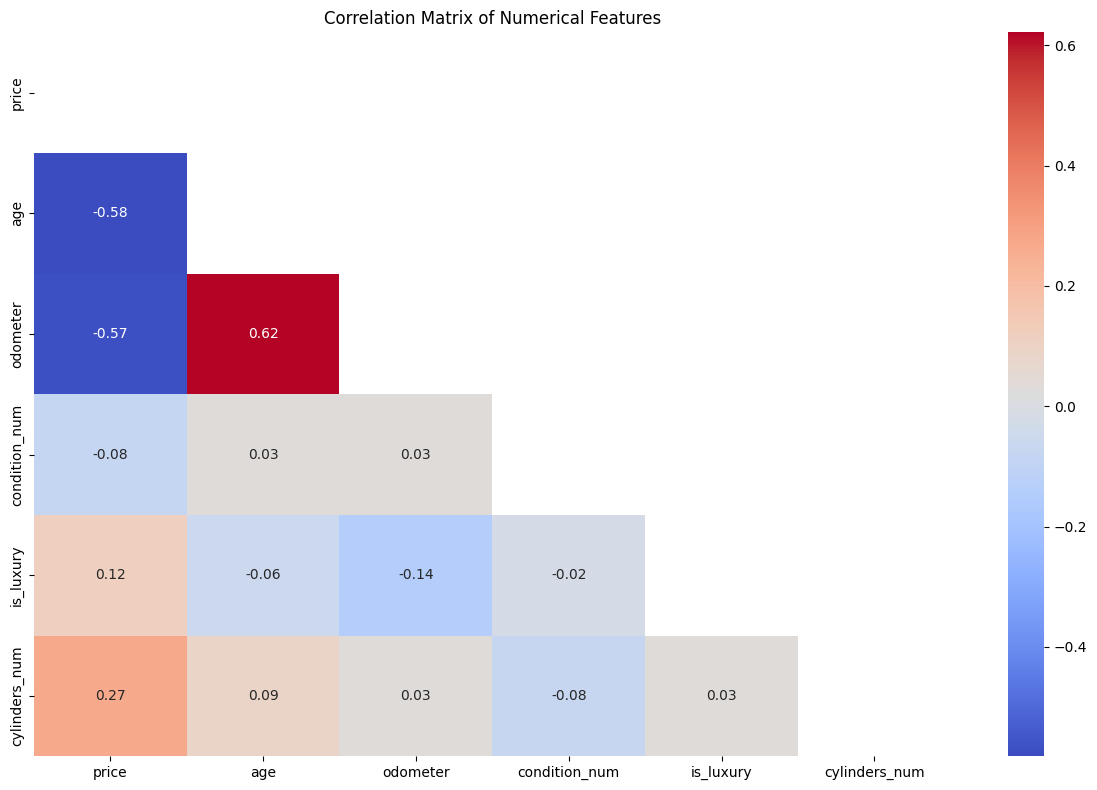

In [329]:
selected_cols = [
    'price',
    'age',
    'odometer',
    'condition_num',
    'is_luxury',
    'cylinders_num'
]
corr_matrix = plot_df[selected_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()

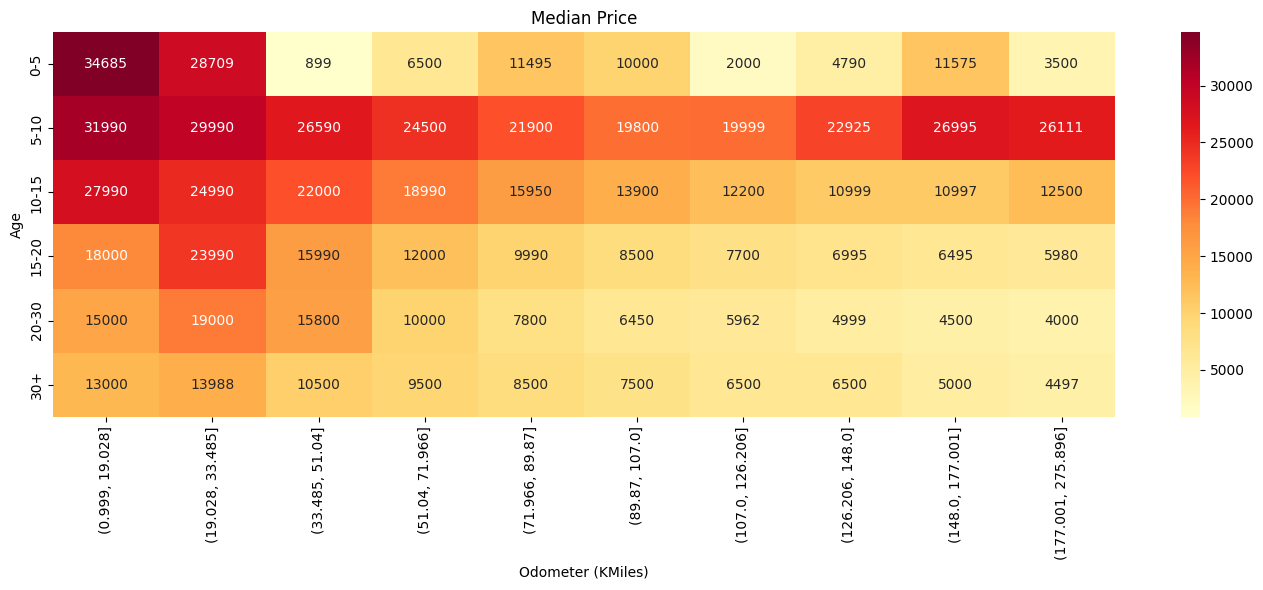

In [330]:
# Age bins
plot_df['age_bin'] = pd.cut(
    plot_df['age'],
    bins=[0, 5, 10, 15, 20, 30, 50],
    labels=['0-5', '5-10', '10-15', '15-20', '20-30', '30+']
)

# Odometer bins in K-miles
plot_df['odometer_bin'] = pd.qcut(
    plot_df['odometer'] / 1000,
    q=10,
    duplicates='drop'
)

# Pivot table
heatmap_data = plot_df.pivot_table(
    values='price',
    index='age_bin',
    columns='odometer_bin',
    aggfunc='median'
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Median Price')
plt.xlabel('Odometer (KMiles)')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Vehicle Price vs Log Mileage by Age')

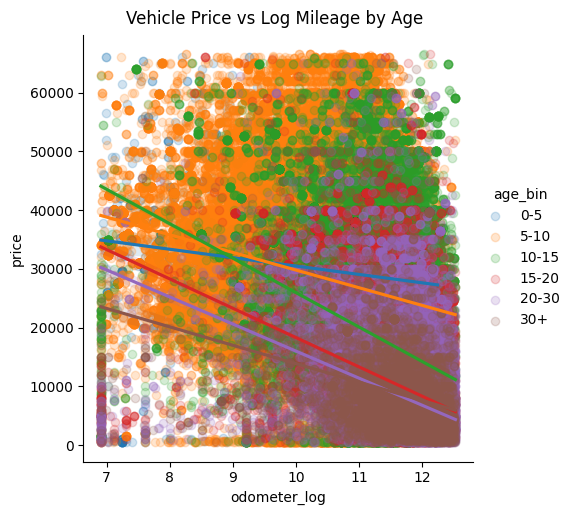

In [331]:
g = sns.lmplot(
    data=plot_df,
    x='odometer_log',
    y='price',
    hue='age_bin',
    height=5,
    scatter_kws={'alpha': 0.2}
)

g.fig.suptitle('Vehicle Price vs Log Mileage by Age', y=1.02)

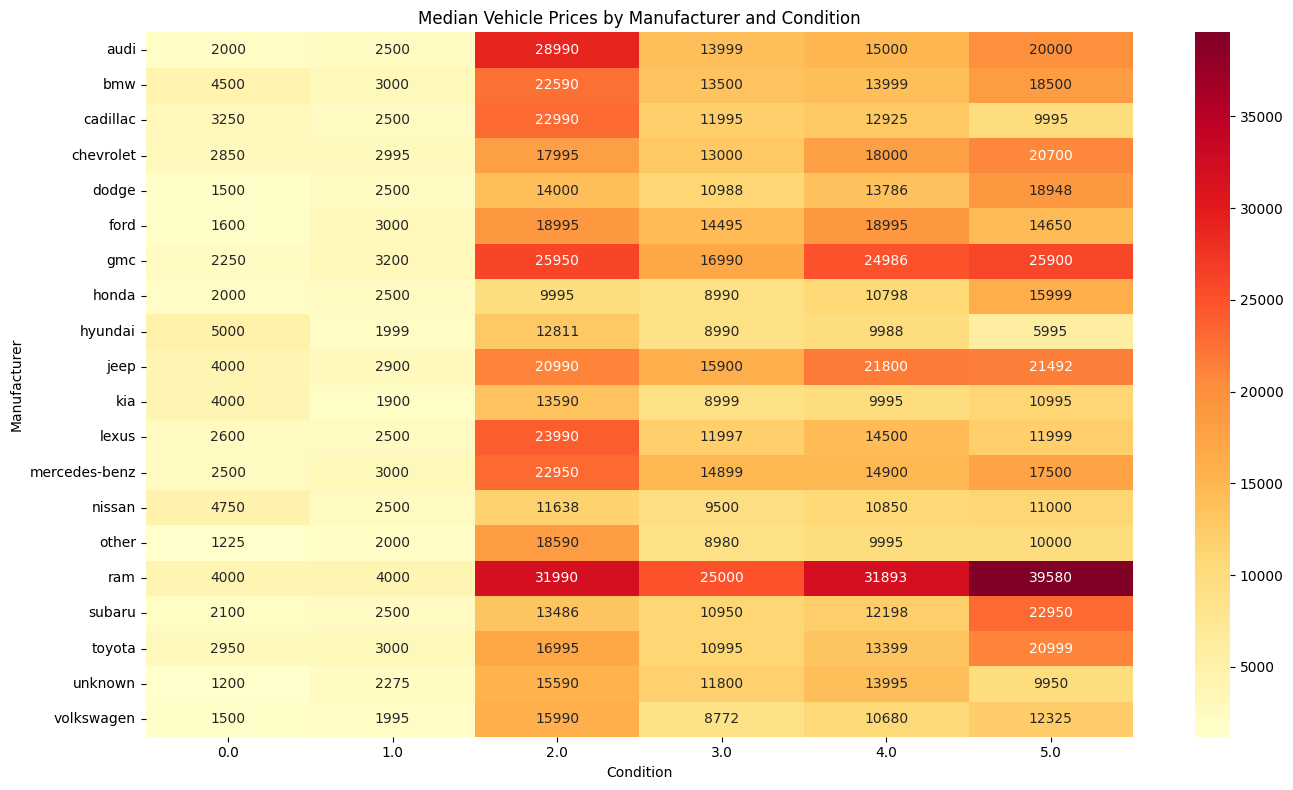

In [332]:
top_makes = plot_df['manufacturer'].value_counts().head(20).index

filtered_df = plot_df[
    plot_df['manufacturer'].isin(top_makes)
]

median_prices = (
    filtered_df.groupby(['manufacturer', 'condition_num'])['price']
    .median()
    .unstack()
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    median_prices,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title('Median Vehicle Prices by Manufacturer and Condition')
plt.xlabel('Condition')
plt.ylabel('Manufacturer')

plt.tight_layout()
plt.show()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [333]:
X = vehicles.drop(columns='price') 
y = np.log1p(vehicles['price'])  #Using log price instead of default 'price' column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [334]:
def print_features(title, features):
    print(f"{title} ({len(features)}):")
    for f in features:
        print(f"  - {f}")
    print()

num_poly_features = ['age', 'odometer_log']
num_features = list (set(X.select_dtypes(exclude=['str', 'category']).columns)-set(num_poly_features))
cat_features = X.select_dtypes(include=['str', 'category']).columns 

print_features("Polynomial features", num_poly_features)
print_features("Other numeric features", num_features)
print_features("Categorical features", cat_features)


Polynomial features (2):
  - age
  - odometer_log

Other numeric features (5):
  - condition_num
  - cylinders_missing
  - is_luxury
  - cylinders_num
  - condition_missing

Categorical features (8):
  - manufacturer
  - fuel
  - transmission
  - drive
  - type_grouped
  - title_grouped
  - color_grouped
  - region



In [335]:
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('num_poly', poly_pipe, num_poly_features),
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

## Linear Regresson Model

In [336]:
lin_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])


In [337]:
lin_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_poly', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [338]:
lin_pipe.fit (X_train, y_train)
y_train_pred = lin_pipe.predict (X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
y_test_pred = lin_pipe.predict (X_test)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"{'Train MSE':<15}: {train_mse:.4f}")
print(f"{'Test MSE':<15}: {test_mse:.4f}")

Train MSE      : 0.2665
Test MSE       : 0.2652


In [339]:
coefs = lin_pipe.named_steps['model'].coef_
feature_names = lin_pipe.named_steps['preprocess'].get_feature_names_out()
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)
coef_df

,feature,coef,abs_coef
4,num_poly__odometer_log^2,-1.455829,1.455829
1,num_poly__odometer_log,1.428222,1.428222
3,num_poly__age odometer_log,-1.103456,1.103456
50,cat__title_grouped_bad,-0.757151,0.757151
31,cat__fuel_diesel,0.524363,0.524363
...,...,...,...
62,cat__region_South,0.010477,0.010477
6,num__cylinders_missing,0.008823,0.008823
60,cat__region_Midwest,-0.007943,0.007943
49,cat__type_grouped_van,0.001268,0.001268


## Ridge Model

In [343]:
ridge_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge())
])

In [344]:
ridge_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_poly', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [347]:
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

y_pred = best_ridge.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)

display(HTML(f"""
Best alpha: <b>{ridge_grid.best_params_['model__alpha']}</b><br>
Best CV MSE: <b>{-ridge_grid.best_score_:.4f}</b><br>
Test MSE: <b>{test_mse:.4f}</b>
"""))

In [ ]:
ridge_results = pd.DataFrame(ridge_grid.cv_results_)

ridge_results[['param_model__alpha', 'mean_test_score', 'std_test_score']]

In [348]:
feature_names = best_ridge.named_steps['preprocess'].get_feature_names_out()
coefs = best_ridge.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

coef_df.head(10)

,feature,coef,abs_coef
4,num_poly__odometer_log^2,-1.455296,1.455296
1,num_poly__odometer_log,1.427828,1.427828
3,num_poly__age odometer_log,-1.104292,1.104292
50,cat__title_grouped_bad,-0.756690,0.756690
31,cat__fuel_diesel,0.524165,0.524165
2,num_poly__age^2,0.416951,0.416951
51,cat__title_grouped_clean,0.379139,0.379139
52,cat__title_grouped_other,0.238218,0.238218
28,cat__manufacturer_toyota,0.221345,0.221345
0,num_poly__age,0.198119,0.198119


In [350]:
result = permutation_importance(
    best_ridge,
    X_test,
    y_test,
    scoring='neg_mean_squared_error',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values('importance_mean', ascending=False)

perm_imp

,feature,importance_mean,importance_std
4,age,0.325572,0.001732
5,odometer_log,0.122641,0.001193
1,fuel,0.048991,0.000763
12,is_luxury,0.029648,0.000435
3,drive,0.029221,0.000489
6,cylinders_num,0.028600,0.000447
0,manufacturer,0.023716,0.000328
10,type_grouped,0.014873,0.000349
2,transmission,0.011241,0.000226
9,condition_missing,0.010943,0.000231


In [358]:
results_full = X_test.copy()

results_full['actual'] = np.expm1(y_test)
results_full['predicted'] = np.expm1(y_pred)
results_full['abs_error'] = (results_full['predicted']-results_full['actual']).abs()
results_full['pct_error'] = results_full['abs_error'] / results_full['actual']

results_full.sample(10, random_state=42)

,manufacturer,fuel,transmission,drive,age,odometer_log,cylinders_num,cylinders_missing,condition_num,condition_missing,type_grouped,title_grouped,is_luxury,color_grouped,region,actual,predicted,abs_error,pct_error
304806,chevrolet,gas,other,unknown,6.0,10.080545,6.0,0,2.0,0,other,clean,0,light,South,29990.0,31700.753500,1710.753500,0.057044
390507,jeep,gas,manual,4wd,14.0,11.974865,6.0,0,2.0,0,SUV,clean,0,color,South,12475.0,11905.303361,569.696639,0.045667
266093,jeep,other,other,4wd,8.0,10.109810,6.0,1,2.0,0,SUV,clean,0,other,Northeast,39990.0,32381.622720,7608.377280,0.190257
184197,ford,gas,automatic,unknown,15.0,11.862307,6.0,1,3.0,0,other,clean,0,light,South,7195.0,8901.555705,1706.555705,0.237186
296289,other,gas,automatic,fwd,11.0,10.773127,4.0,0,3.0,0,car,clean,0,neutral,Midwest,9995.0,10079.890042,84.890042,0.008493
98834,other,gas,automatic,fwd,13.0,11.454321,4.0,0,3.0,0,SUV,clean,1,dark,South,18900.0,10374.223546,8525.776454,0.451099
237665,chevrolet,gas,automatic,fwd,18.0,12.145021,4.0,0,2.0,0,car,clean,0,other,South,3800.0,3553.014850,246.985150,0.064996
315579,other,gas,automatic,rwd,16.0,11.410505,6.0,0,2.0,1,car,clean,0,light,West,9999.0,10470.172937,471.172937,0.047122
110224,bmw,gas,automatic,rwd,9.0,10.739197,6.0,1,3.0,0,car,clean,1,other,South,26997.0,25828.914010,1168.085990,0.043267
190814,other,gas,automatic,fwd,17.0,11.386160,6.0,0,2.0,0,other,clean,0,neutral,Northeast,6950.0,5996.600513,953.399487,0.137180


## Lasso Model

In [352]:
lasso_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', Lasso(max_iter=10000))
])

In [353]:
lasso_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_poly', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [354]:
param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    lasso_pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best alpha:", lasso_grid.best_params_)
print("Best CV MSE:", -lasso_grid.best_score_)

Best alpha: {'model__alpha': 0.001}
Best CV MSE: 0.2697279544632504


In [355]:
best_lasso = lasso_grid.best_estimator_
coefs = best_lasso.named_steps['model'].coef_
feature_names = best_lasso.named_steps['preprocess'].get_feature_names_out()

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs
})

coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

coef_df.head(10)


,feature,coef,abs_coef
4,num_poly__odometer_log^2,-1.042898,1.042898
1,num_poly__odometer_log,0.992860,0.992860
3,num_poly__age odometer_log,-0.893613,0.893613
31,cat__fuel_diesel,0.570060,0.570060
2,num_poly__age^2,0.409577,0.409577
51,cat__title_grouped_clean,0.189040,0.189040
48,cat__type_grouped_truck,0.182453,0.182453
41,cat__drive_4wd,0.174874,0.174874
43,cat__drive_rwd,0.174409,0.174409
28,cat__manufacturer_toyota,0.165900,0.165900


In [356]:
y_pred = best_lasso.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)

print("Test MSE:", test_mse)

Test MSE: 0.26819092949783935


## Modeling Results

Several regression models were evaluated, including:

- Linear Regression
- Ridge Regression
- Lasso Regression

Best Performing Models

Regularized models such as Ridge produced the most stable and reliable results.

These models successfully balanced:

- Predictive accuracy
- Generalization performance
- Overfitting control

Polynomial feature engineering further improved performance by capturing nonlinear relationships between vehicle age and mileage.

## Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

## Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

Based on the analysis, the following strategies may improve inventory management and profitability:

#### Prioritize Inventory With:
- Lower mileage
- Moderate vehicle age
- Clean title status
- Reliable manufacturers

#### Be Cautious With:
- Salvage or rebuilt titles
- Extremely high-mileage vehicles
- Very old inventory
- Vehicles with inconsistent or missing information

#### Pricing Strategy Recommendations
- Use mileage and age together when evaluating value
- Consider manufacturer-specific depreciation patterns
